# Classification de Sentiment en Fongbé
## Modèles de Machine Learning Classiques

Ce notebook présente le pipeline d'entraînement et d'évaluation de modèles de machine learning classiques (Multinomial Naive Bayes, Random Forest, Soft Voting Classifier) pour la classification de sentiment sur un corpus de phrases en fongbé.

### Structure de l'expérimentation :
1. **Sélection de modèle** : Entraînement sur le jeu d'entraînement (70%) et évaluation sur le jeu de validation (15%).
2. **Ré-entraînement final** : Entraînement du modèle sélectionné sur le jeu d'entraînement étendu (Train + Validation = 85%).
3. **Évaluation finale** : Mesure des performances sur le jeu de test indépendant (15%).
4. **Exportation** : Sauvegarde du pipeline sous format `.joblib`.

| Label | Sentiment |
|-------|-----------|
| 0 | Neutre |
| 1 | Négatif |
| 2 | Positif |

## 1. Chargement des bibliothèques

In [1]:
#%pip install imbalanced-learn


In [2]:
import pandas as pd
import numpy as np
import os
import joblib
from imblearn.over_sampling import RandomOverSampler

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
)
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 2. Chargement et préparation du dataset

Nombre de phrases valides : 87,126

Distribution des classes :
label
0    53014
1    19789
2    14323
Name: count, dtype: int64

Proportions (%) :
label
0    60.8
1    22.7
2    16.4
Name: proportion, dtype: float64


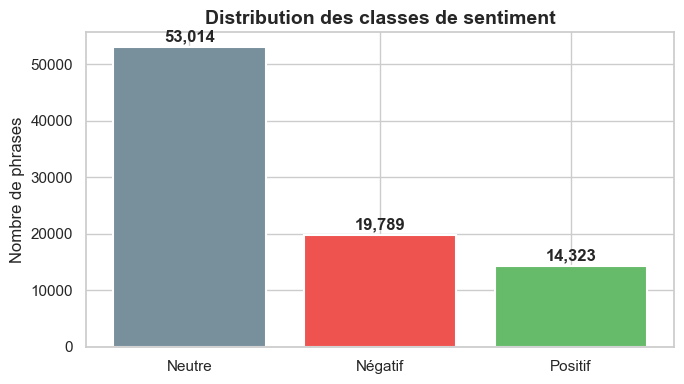

In [3]:
df = pd.read_csv("../data/corpus_final.csv", sep="|")

df["sentiment_final"] = pd.to_numeric(df["sentiment_final"], errors="coerce")
df = df.dropna(subset=["fon", "sentiment_final"])
df["label"] = df["sentiment_final"].astype(int)

print(f"Nombre de phrases valides : {len(df):,}")
print("\nDistribution des classes :")
print(df["label"].value_counts().sort_index())
print("\nProportions (%) :")
print((df["label"].value_counts(normalize=True).sort_index() * 100).round(1))

LABEL_NAMES = {0: "Neutre", 1: "Négatif", 2: "Positif"}
LABEL_COLORS = {0: "#78909C", 1: "#EF5350", 2: "#66BB6A"}

plt.figure(figsize=(7, 4))
counts = df["label"].value_counts().sort_index()
bars = plt.bar(
    [LABEL_NAMES[i] for i in counts.index],
    counts.values,
    color=[LABEL_COLORS[i] for i in counts.index],
    edgecolor="white",
    linewidth=1.5,
)
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
             f"{val:,}", ha="center", va="bottom", fontweight="bold")

plt.title("Distribution des classes de sentiment", fontsize=14, fontweight="bold")
plt.ylabel("Nombre de phrases")
plt.tight_layout()
plt.show()

## 3. Partitionnement des données (Train / Validation / Test)

In [4]:
# Conversion explicite en tableaux NumPy standard pour compatibilité avec scikit-learn
X = np.array(df["fon"].astype(str).tolist(), dtype=object)
y = np.array(df["label"].tolist(), dtype=int)

# Split stratifié : 70% Train, 15% Validation, 15% Test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Jeu d'entraînement (Train) : {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Jeu de validation (Val)    : {len(X_val):,} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Jeu de test (Test)         : {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")
print(f"Total                      : {len(X):,}")

Jeu d'entraînement (Train) : 60,988 (70.0%)
Jeu de validation (Val)    : 13,069 (15.0%)
Jeu de test (Test)         : 13,069 (15.0%)
Total                      : 87,126


## 4. Entrainement des modèles et sélection du plus performant

In [5]:
tfidf_select = TfidfVectorizer(
    max_features=30_000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    strip_accents=None,
    min_df=2,
)

X_train_tfidf = tfidf_select.fit_transform(X_train)
X_val_tfidf = tfidf_select.transform(X_val)

In [6]:

# --- APPLICATION DE RANDOMOVERSAMPLER SUR LE TRAIN ---
ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train_tfidf, y_train)
print(f"Distribution avant rééquilibrage : {np.bincount(y_train)}")
print(f"Distribution après rééquilibrage : {np.bincount(y_train_res)}")

Distribution avant rééquilibrage : [37110 13852 10026]
Distribution après rééquilibrage : [37110 37110 37110]


In [7]:
# 1. Multinomial Naive Bayes
from sklearn.model_selection import GridSearchCV

# Définir les paramètres à tester
param_grid = {'alpha': [0.09, 0.1, 0.15, ]}

# Lancer la recherche sur le Train
grid_mnb = GridSearchCV(MultinomialNB(), param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_mnb.fit(X_train_res, y_train_res)

# Récupérer le meilleur modèle
print("Meilleur paramètre alpha :", grid_mnb.best_params_)

mnb = grid_mnb.best_estimator_
pred_val_mnb = mnb.predict(X_val_tfidf)

print(f"Multinomial Naive Bayes -> Accuracy: {accuracy_score(y_val, pred_val_mnb):.4f}")

Meilleur paramètre alpha : {'alpha': 0.09}
Multinomial Naive Bayes -> Accuracy: 0.6505


In [9]:
# 2. Random Forest
import optuna

# Désactiver les logs verbeux d'optuna si souhaité
optuna.logging.set_verbosity(optuna.logging.WARNING)
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 250)
    max_depth = trial.suggest_int('max_depth', 10, 80)
    
    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train_res, y_train_res)
    preds = rf.predict(X_val_tfidf)
    return accuracy_score(y_val, preds)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)
print("Meilleurs hyperparamètres trouvés :", study.best_params)

# Entraînement avec les meilleurs paramètres 
rf = RandomForestClassifier(
    **study.best_params,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_res, y_train_res)
pred_val_rf = rf.predict(X_val_tfidf)
print(f"Random Forest   -> Accuracy: {accuracy_score(y_val, pred_val_rf):.4f}")

Meilleurs hyperparamètres trouvés : {'n_estimators': 144, 'max_depth': 76}
Random Forest   -> Accuracy: 0.7136


In [10]:
# 3. Soft Voting Classifier
voting_clf = VotingClassifier(estimators=[("mnb", mnb), ("rf", rf)], voting="soft", n_jobs=-1)
voting_clf.fit(X_train_res, y_train_res)
pred_val_voting = voting_clf.predict(X_val_tfidf)

print(f"Soft Voting Classifier  -> Accuracy: {accuracy_score(y_val, pred_val_voting):.4f}")

Soft Voting Classifier  -> Accuracy: 0.6818


In [11]:
# Résultats de validation
val_results = [
    {"Modèle": "Multinomial Naive Bayes", "Accuracy Val": accuracy_score(y_val, pred_val_mnb), "F1 Macro Val": f1_score(y_val, pred_val_mnb, average="macro")},
    {"Modèle": "Random Forest", "Accuracy Val": accuracy_score(y_val, pred_val_rf), "F1 Macro Val": f1_score(y_val, pred_val_rf, average="macro")},
    {"Modèle": "Soft Voting Classifier", "Accuracy Val": accuracy_score(y_val, pred_val_voting), "F1 Macro Val": f1_score(y_val, pred_val_voting, average="macro")},
]

df_val = pd.DataFrame(val_results)
print("=" * 65)
print("ÉVALUATION SUR LE JEU DE VALIDATION")
print("=" * 65)
print(df_val.to_string(index=False))

best_architecture = df_val.sort_values(by="Accuracy Val", ascending=False).iloc[0]["Modèle"]
print(f"\nModèle sélectionné : {best_architecture}")

ÉVALUATION SUR LE JEU DE VALIDATION
                 Modèle  Accuracy Val  F1 Macro Val
Multinomial Naive Bayes      0.650471      0.612108
          Random Forest      0.713597      0.642919
 Soft Voting Classifier      0.681766      0.640479

Modèle sélectionné : Random Forest


## 5. Ré-entraînement du modèle sélectionné sur l'ensemble Train + Validation

In [12]:
X_train_val = np.concatenate([X_train, X_val])
y_train_val = np.concatenate([y_train, y_val])

print(f"Taille du jeu d'entraînement final (Train + Val) : {len(X_train_val):,} ({len(X_train_val)/len(X)*100:.1f}%)")

# Vectoriseur TF-IDF au niveau des caractères (3 à 5 n-grams)
tfidf_final = TfidfVectorizer(
    max_features=30_000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    strip_accents=None,
    min_df=2,
)

X_train_val_tfidf = tfidf_final.fit_transform(X_train_val)
X_test_tfidf = tfidf_final.transform(X_test)

print(f"Taille du vocabulaire TF-IDF : {len(tfidf_final.vocabulary_):,} termes")

# --- APPLICATION DE RANDOMOVERSAMPLER SUR L'ENSEMBLE TRAIN + VAL (85%) ---
ros_final = RandomOverSampler(random_state=42)
X_train_val_res, y_train_val_res = ros_final.fit_resample(X_train_val_tfidf, y_train_val)
# 1. Extraction des meilleurs hyperparamètres issus de l'optimisation
best_alpha = grid_mnb.best_params_['alpha']
best_rf_params = study.best_params

# 2. Instanciation du modèle sélectionné avec ses vrais paramètres optimaux
if best_architecture == "Multinomial Naive Bayes":
    final_model = MultinomialNB(alpha=best_alpha)

elif best_architecture == "Random Forest":
    final_model = RandomForestClassifier(
        **best_rf_params,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

else:  # Soft Voting Classifier
    mnb_m = MultinomialNB(alpha=best_alpha)
    rf_m = RandomForestClassifier(
        **best_rf_params,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
    final_model = VotingClassifier(
        estimators=[("mnb", mnb_m), ("rf", rf_m)],
        voting="soft",
        n_jobs=-1
    )

# 3. Ré-entraînement sur les 85% de données
print(f"Ré-entraînement du modèle '{best_architecture}' avec ses hyperparamètres optimisés...")
final_model.fit(X_train_val_res, y_train_val_res)
print(f"✅ Ré-entraînement du modèle '{best_architecture}' terminé.")


Taille du jeu d'entraînement final (Train + Val) : 74,057 (85.0%)
Taille du vocabulaire TF-IDF : 30,000 termes
Ré-entraînement du modèle 'Random Forest' avec ses hyperparamètres optimisés...
✅ Ré-entraînement du modèle 'Random Forest' terminé.


## 6. Évaluation sur le jeu de test

RÉSULTATS DU JEU DE TEST — RANDOM FOREST
Accuracy       : 0.7190
F1-Score Macro  : 0.6520
F1-Score Weighted: 0.7147

              precision    recall  f1-score   support

      Neutre       0.78      0.83      0.80      7952
     Négatif       0.64      0.54      0.59      2969
     Positif       0.57      0.56      0.57      2148

    accuracy                           0.72     13069
   macro avg       0.66      0.64      0.65     13069
weighted avg       0.71      0.72      0.71     13069



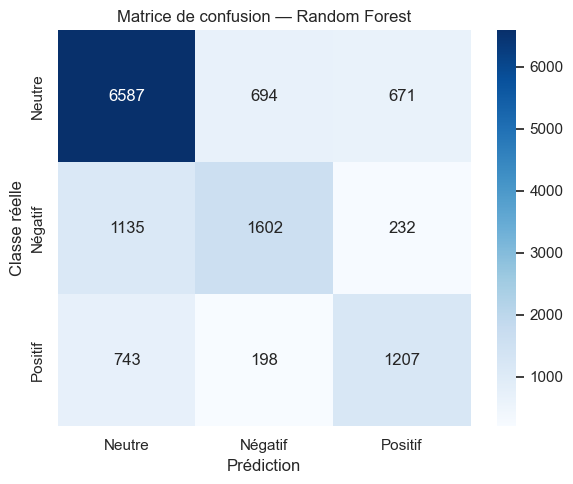

In [13]:
y_test_pred = final_model.predict(X_test_tfidf)

test_acc = accuracy_score(y_test, y_test_pred)
test_f1_macro = f1_score(y_test, y_test_pred, average="macro")
test_f1_weighted = f1_score(y_test, y_test_pred, average="weighted")

print("=" * 65)
print(f"RÉSULTATS DU JEU DE TEST — {best_architecture.upper()}")
print("=" * 65)
print(f"Accuracy       : {test_acc:.4f}")
print(f"F1-Score Macro  : {test_f1_macro:.4f}")
print(f"F1-Score Weighted: {test_f1_weighted:.4f}")
print()
print(classification_report(y_test, y_test_pred, target_names=["Neutre", "Négatif", "Positif"]))

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Neutre", "Négatif", "Positif"],
            yticklabels=["Neutre", "Négatif", "Positif"])
plt.title(f"Matrice de confusion — {best_architecture}")
plt.xlabel("Prédiction")
plt.ylabel("Classe réelle")
plt.tight_layout()
plt.show()

## 7. Sauvegarde du pipeline

In [15]:
os.makedirs("../models", exist_ok=True)

# Vectorizer (partagé par les 3 modèles)
joblib.dump(tfidf_final, "../models/tfidf.joblib")

# Les 3 modèles
joblib.dump(mnb, "../models/mnb_model.joblib")
joblib.dump(rf, "../models/rf_model.joblib")
joblib.dump(final_model, "../models/voting_model.joblib")

print("Fichiers sauvegardés dans models/ :")
print("   - tfidf.joblib          (vectorizer TF-IDF)")
print("   - mnb_model.joblib      (Multinomial Naive Bayes)")
print("   - rf_model.joblib       (Random Forest)")
print("   - voting_model.joblib   (Soft Voting Classifier)")


Fichiers sauvegardés dans models/ :
   - tfidf.joblib          (vectorizer TF-IDF)
   - mnb_model.joblib      (Multinomial Naive Bayes)
   - rf_model.joblib       (Random Forest)
   - voting_model.joblib   (Soft Voting Classifier)
